# Probability Distribution Functions: A Data Scientist's Crash Course

*From raw data to deep pattern recognition — no calculus required.*

---

## 1. Big Picture Motivation: Why Do Distributions Exist?

Imagine you're a hiring manager at a tech company. You collected the salaries of 1,000 employees across the industry. Someone asks: *"What do salaries look like?"*

You could answer: **"The average is $85,000."**

But that leaves so many questions unanswered:
- Is everyone clustered tightly around $85k, or wildly spread out?
- Are there a handful of executives pulling the average up?
- What's the most *common* salary — is it even close to $85k?
- What's the chance a randomly chosen employee earns over $120k?

A single number — the mean — can't answer any of that. This is exactly why **probability distributions were invented.**

> **A probability distribution is a complete picture of how values in a dataset are spread across all possible outcomes.** It doesn't just tell you the center — it tells you the *shape*, the *spread*, the *likelihood* of any particular value occurring.

### The Core Idea: Data Has Shape

Think of data like a landscape. Descriptive statistics (mean, median, etc.) give you GPS coordinates for a few landmarks. A probability distribution gives you the **full topographic map**.

Here are some real-world examples of patterns data follows:

| Data | Pattern |
|---|---|
| Human heights | Symmetric bell curve — most people near average |
| Salaries | Right-skewed — most earn moderate amounts, a few earn enormous sums |
| Dice rolls | Flat — every outcome equally likely |
| Customer support calls per hour | Lumpy — random arrivals clustering around a rate |
| Time between bus arrivals | Decay curve — short waits are common, long waits are rare |

Each of these *shapes* has a name. Those named shapes are **probability distributions**. They're reusable mathematical templates humans discovered by noticing that many real-world phenomena follow the same patterns again and again.

---

## 2. Connect to Descriptive Statistics

Before we visualize distributions, let's make sure you understand what descriptive statistics *can* tell you — and where they fall short.

### What Descriptive Statistics Tell You

| Statistic | What It Describes |
|---|---|
| **Mean** | The arithmetic center of the data |
| **Median** | The middle value — splits data 50/50 |
| **Mode** | The most frequently occurring value |
| **Variance** | Average squared distance from the mean |
| **Std Dev** | Typical spread from the mean (same units as data) |
| **Quartiles** | Data split into 25% chunks (Q1, Q2, Q3) |
| **Percentiles** | What % of data falls below a given value |

### The Critical Limitation

Here's a fact that surprises most beginners:

**Two completely different datasets can have the exact same mean, median, and standard deviation — but look entirely different.**

This is known as **Anscombe's Quartet** — a famous example where 4 datasets share nearly identical statistics but have wildly different shapes and patterns.

Summary statistics *summarize*. They compress rich information into a few numbers. Distributions **preserve the full picture**.

> Think of it this way: a mean is like a movie's average review score. A distribution is like reading all the individual reviews — you discover whether people loved it or hated it, whether critics and audiences disagreed, whether it polarized viewers.

---

## 3. Building Our Synthetic Dataset

Let's create a realistic dataset we'll use throughout this lesson. We'll simulate a company's employee and operations data.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Reproducibility — same random numbers every run
np.random.seed(42)

n = 1000  # 1000 employees / records

# --- Salary ---
# Most employees earn moderate salaries, but a few executives earn a lot.
# This creates a right-skewed distribution (more on this later).
salary = np.random.lognormal(mean=11.2, sigma=0.4, size=n)

# --- Age ---
# Ages cluster around mid-career. Roughly bell-shaped.
age = np.random.normal(loc=38, scale=8, size=n).clip(22, 65)

# --- Delivery Time (days) ---
# Most deliveries arrive quickly; occasional delays push the tail right.
delivery_time = np.random.exponential(scale=3.5, size=n)

# --- Customer Spending ($) ---
# A mix: most spend modestly, some spend a lot. Also right-skewed.
spending = np.random.lognormal(mean=4.5, sigma=0.8, size=n)

# --- Support Tickets per Day ---
# Count of events happening at a random rate — classic Poisson behavior.
tickets = np.random.poisson(lam=4, size=n)

# --- Hired This Quarter (yes/no) ---
# Binary outcome: each person either was hired this quarter or wasn't.
hired_this_quarter = np.random.binomial(n=1, p=0.15, size=n)

# --- Department (categorical) ---
departments = np.random.choice(
    ['Engineering', 'Sales', 'Marketing', 'HR', 'Finance'],
    size=n,
    p=[0.35, 0.25, 0.20, 0.10, 0.10]
)

# Assemble into a DataFrame
df = pd.DataFrame({
    'salary': salary.round(2),
    'age': age.round(1),
    'delivery_time_days': delivery_time.round(2),
    'customer_spending': spending.round(2),
    'support_tickets_per_day': tickets,
    'hired_this_quarter': hired_this_quarter,
    'department': departments
})

print(df.shape)       # (1000, 7) — confirm 1000 rows, 7 columns
print(df.head())      # Preview first 5 rows
print(df.dtypes)      # Column data types


## check statistical summary of the data
print(df.describe().round(2))

(1000, 7)
      salary   age  delivery_time_days  customer_spending  \
0   89204.40  49.2                1.83             142.38   
1   69195.72  45.4                0.24              21.57   
2   94757.42  38.5                1.50              67.51   
3  134485.54  32.8                0.41             114.54   
4   66591.93  43.6                5.78             104.28   

   support_tickets_per_day  hired_this_quarter   department  
0                        7                   0    Marketing  
1                        3                   0        Sales  
2                        3                   0  Engineering  
3                        5                   0  Engineering  
4                        2                   0  Engineering  
salary                     float64
age                        float64
delivery_time_days         float64
customer_spending          float64
support_tickets_per_day      int64
hired_this_quarter           int64
department                     str
dtype:

**What each line does:**
- `np.random.seed(42)` — fixes randomness so results are reproducible
- `np.random.lognormal(...)` — generates skewed salary data (we'll explain lognormal later)
- `.clip(22, 65)` — ensures ages stay in a realistic range
- `np.random.exponential(...)` — generates delivery times that decay naturally
- `np.random.poisson(lam=4)` — generates random counts of events per day
- `np.random.binomial(n=1, p=0.15)` — generates yes/no outcomes (15% chance of "yes")
- `pd.DataFrame({...})` — assembles all columns into a table

```python
# Descriptive statistics — the "summary" view
print(df.describe().round(2))
```

This gives you mean, std, min, quartiles, max for every numeric column. Notice how different each column looks — even though they're all just "numbers", they have completely different natures. That's distributions at work.

---

## 4. Visual Introduction to Distributions

Now let's *see* what the data actually looks like. We'll use histograms — the most direct window into a distribution.

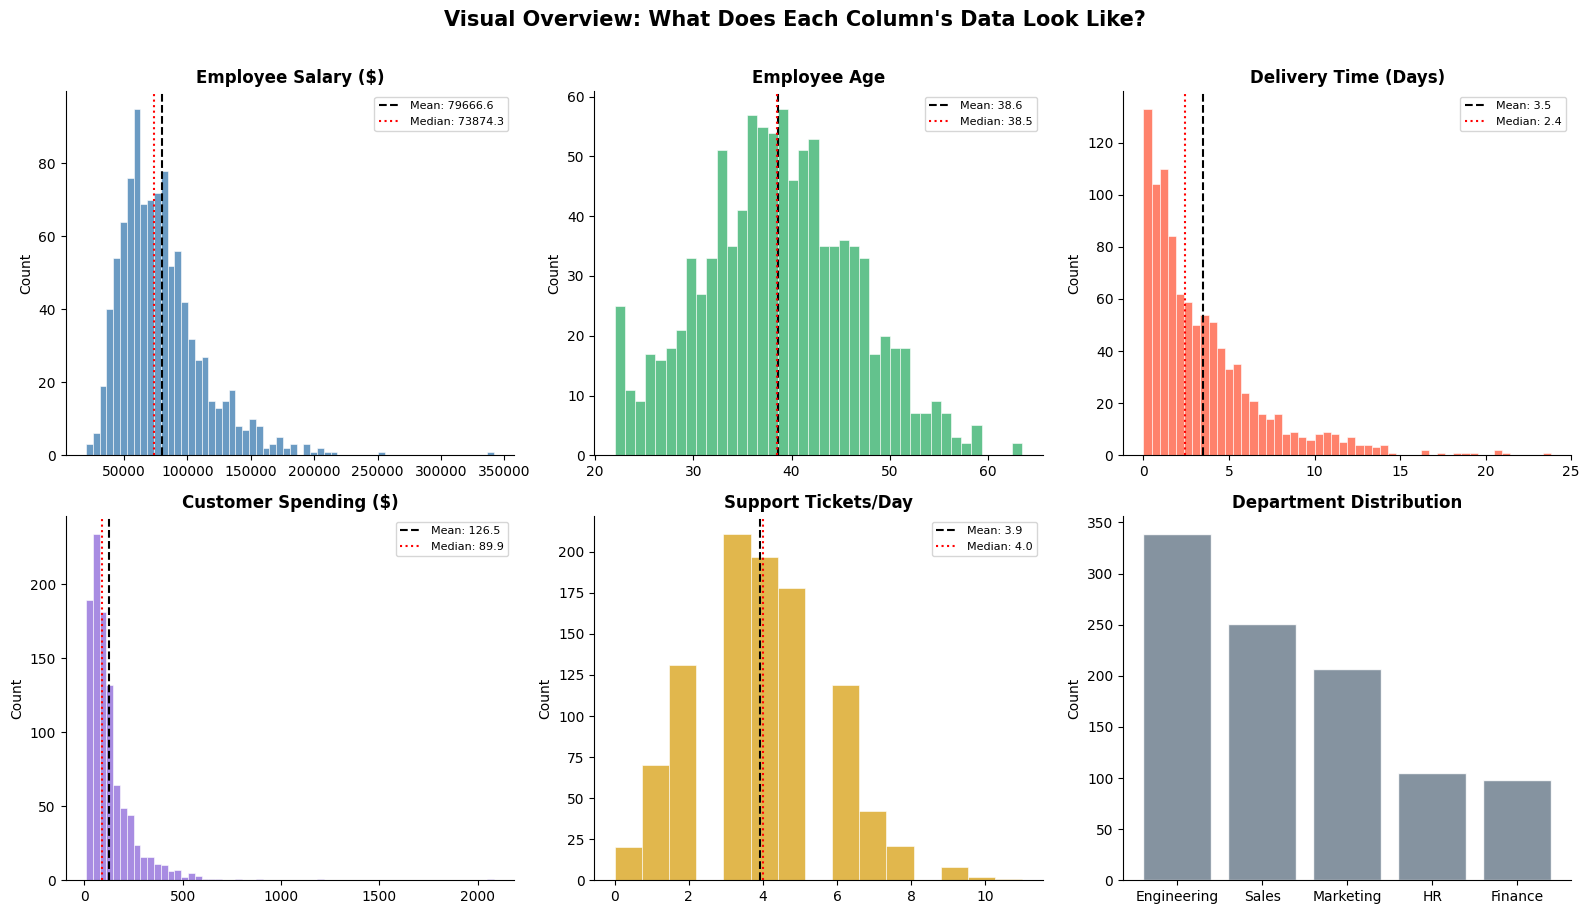

In [6]:

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Visual Overview: What Does Each Column's Data Look Like?",
             fontsize=15, fontweight='bold', y=1.01)

plot_configs = [
    ('salary', 'Employee Salary ($)', 'steelblue', 60),
    ('age', 'Employee Age', 'mediumseagreen', 40),
    ('delivery_time_days', 'Delivery Time (Days)', 'tomato', 50),
    ('customer_spending', 'Customer Spending ($)', 'mediumpurple', 60),
    ('support_tickets_per_day', 'Support Tickets/Day', 'goldenrod', 15),
]

for ax, (col, title, color, bins) in zip(axes.flat, plot_configs):
    ax.hist(df[col], bins=bins, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='red', linestyle=':', linewidth=1.5, label=f'Median: {median_val:.1f}')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Department bar chart
dept_counts = df['department'].value_counts()
axes[1, 2].bar(dept_counts.index, dept_counts.values,
               color='slategray', alpha=0.85, edgecolor='white')
axes[1, 2].set_title('Department Distribution', fontweight='bold')
axes[1, 2].set_ylabel('Count')
axes[1, 2].spines['top'].set_visible(False)
axes[1, 2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('overview_distributions.png', dpi=150, bbox_inches='tight')
plt.show()



### Reading the Charts — What to Look For

When you look at a histogram, train your eye to notice four things:

**1. Shape** — Is it symmetric (bell-shaped)? Skewed to the right (long tail right)? Flat?

**2. Center** — Where does the bulk of the data sit? Notice the dashed mean line vs. dotted median line — when they're far apart, the data is skewed.

**3. Spread** — How wide is the histogram? Wide = high variance. Narrow = data clustered tightly.

**4. Skewness** — For salary and spending, notice the mean (dashed) sits *to the right* of the median (dotted). This happens because a few very high values drag the mean upward. The median is unaffected by extremes.

> **Key insight:** When mean > median, the distribution is right-skewed. When mean < median, it's left-skewed. When they're nearly equal, it's roughly symmetric. This is one of the first things a data scientist checks.

---

## 5. The Six Core Distributions

Now let's study each distribution individually — what it is, what real-world phenomenon it models, and what it looks like.

---

### Distribution 1: The Normal Distribution (The Bell Curve)

#### The Intuition

Imagine measuring the heights of 10,000 adults. Most people are somewhere around average — very few are extremely tall or extremely short. If you pile up those heights in a histogram, you'd get a smooth, symmetric mountain shape.

**Why does this happen?** Because height is influenced by *dozens of independent factors* — genetics, nutrition, environment, etc. When many independent random factors add together, the result tends to be bell-shaped. This is one of the most important ideas in statistics (it's the foundation of the **Central Limit Theorem**, which you'll study later).

The Normal distribution shows up whenever:
- Many small independent factors combine
- Natural biological measurements (height, weight, blood pressure)
- Measurement errors
- Exam scores in large groups
- Manufacturing tolerances

#### Visualizing It



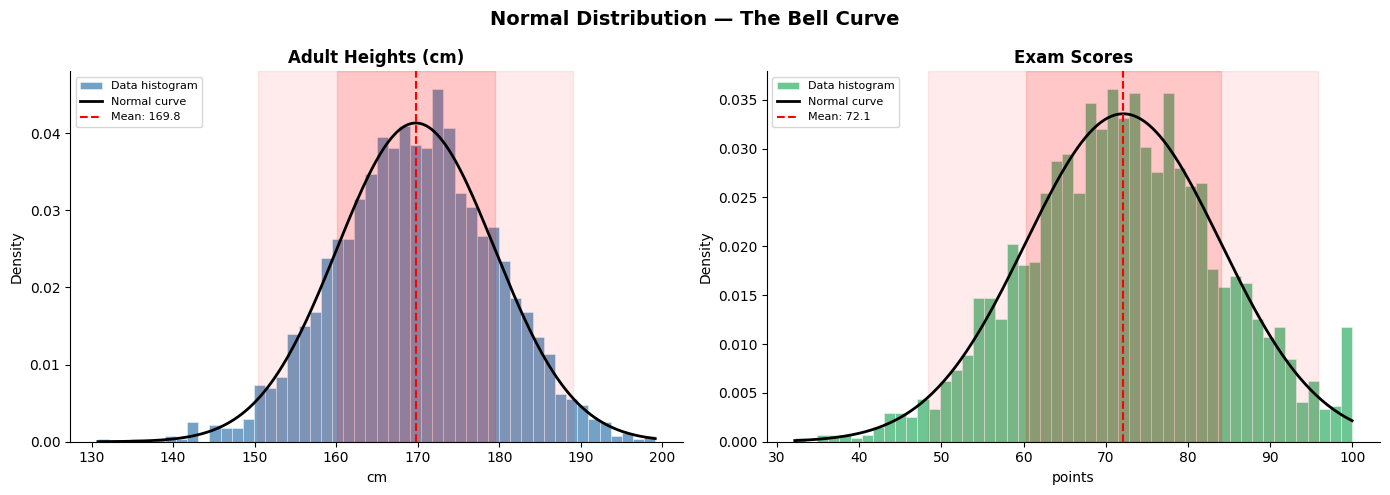

Within 1 std dev: 67.2%  (theory: 68.3%)
Within 2 std devs: 96.0%  (theory: 95.4%)
Within 3 std devs: 99.7%  (theory: 99.7%)


In [7]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Normal Distribution — The Bell Curve", fontsize=14, fontweight='bold')

# Generate normal data
heights = np.random.normal(loc=170, scale=10, size=2000)  # mean=170cm, std=10cm
exam_scores = np.random.normal(loc=72, scale=12, size=2000).clip(0, 100)

for ax, data, label, color, unit in zip(
    axes,
    [heights, exam_scores],
    ['Adult Heights (cm)', 'Exam Scores'],
    ['steelblue', 'mediumseagreen'],
    ['cm', 'points']
):
    ax.hist(data, bins=50, color=color, alpha=0.75, density=True,
            edgecolor='white', linewidth=0.4, label='Data histogram')

    # Overlay theoretical normal curve
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, stats.norm.pdf(x, data.mean(), data.std()),
            color='black', linewidth=2, label='Normal curve')

    # Mark mean and ±1, ±2 std devs
    mu, sigma = data.mean(), data.std()
    ax.axvline(mu, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mu:.1f}')
    for k, alpha in [(1, 0.15), (2, 0.08)]:
        ax.axvspan(mu - k*sigma, mu + k*sigma, alpha=alpha, color='red')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(unit)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('normal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the empirical rule
mu, sigma = heights.mean(), heights.std()
within_1 = np.mean(np.abs(heights - mu) <= sigma) * 100
within_2 = np.mean(np.abs(heights - mu) <= 2*sigma) * 100
within_3 = np.mean(np.abs(heights - mu) <= 3*sigma) * 100

print(f"Within 1 std dev: {within_1:.1f}%  (theory: 68.3%)")
print(f"Within 2 std devs: {within_2:.1f}%  (theory: 95.4%)")
print(f"Within 3 std devs: {within_3:.1f}%  (theory: 99.7%)")


#### The Empirical Rule — The 68-95-99.7 Rule

The shaded regions in the chart reveal one of the most useful rules in all of statistics:

- **68%** of values fall within **1 standard deviation** of the mean
- **95%** fall within **2 standard deviations**
- **99.7%** fall within **3 standard deviations**

This means if heights are normally distributed with mean 170cm and std 10cm:
- 68% of people are between 160–180cm
- 95% are between 150–190cm
- Virtually everyone (99.7%) is between 140–200cm

> **This is why standard deviation is so powerful for normal distributions** — it directly translates into probabilities. For other distributions, this relationship changes significantly.

**Key descriptive stats behavior:**
- Mean = Median = Mode (perfectly symmetric)
- Defined entirely by two parameters: mean (μ) and standard deviation (σ)

---

### Distribution 2: The Uniform Distribution

#### The Intuition

Roll a fair six-sided die. What's the probability of rolling a 1? 1/6. A 3? 1/6. A 6? 1/6. Every outcome has *exactly the same probability*. That's a uniform distribution — flat, equal chances everywhere.

Real-world examples:
- A fair random number generator (random passwords, lottery draws)
- Arrival time of a bus when you have no schedule (uniformly random in the interval)
- Random sampling — when you deliberately want no bias



**Key descriptive stats behavior:**
- Mean sits exactly in the middle of the range
- Std deviation depends only on the width of the range — the wider the range, the higher the spread
- Mean = Median always

> The uniform distribution is the "null hypothesis" of randomness — it's what data looks like when nothing is influencing outcomes in any direction.

---

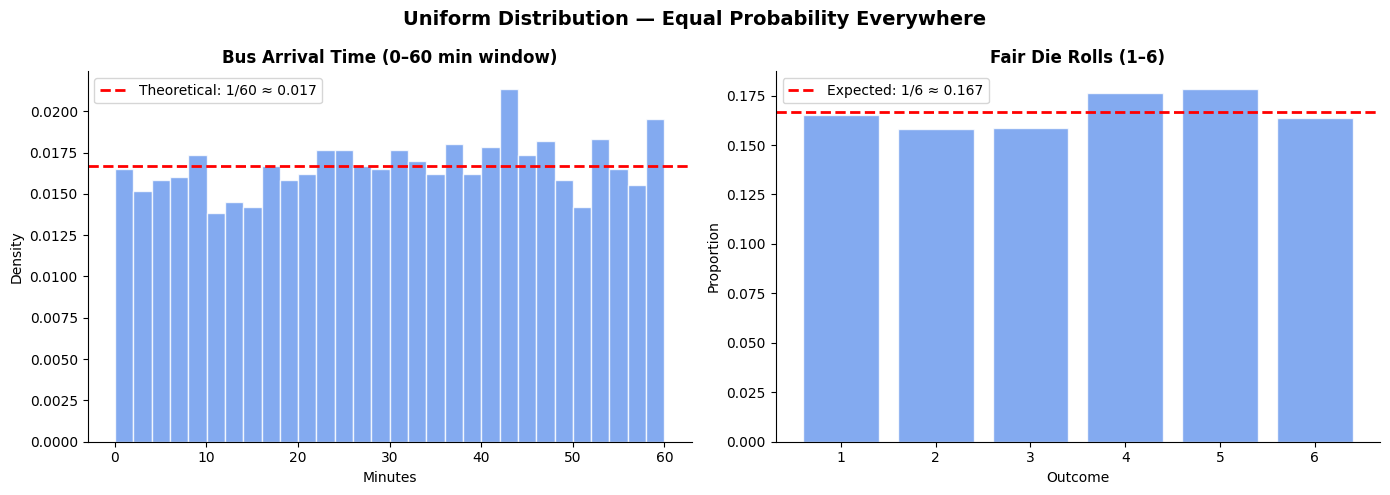

Mean arrival time: 30.7 min (expected: 30.0 min)
Std dev: 17.2 min

Die roll proportions:
1    0.165000
2    0.158000
3    0.158667
4    0.176333
5    0.178333
6    0.163667
Name: count, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Uniform Distribution — Equal Probability Everywhere", fontsize=14, fontweight='bold')

# Continuous uniform: arrival time within a 60-minute window
arrival_minutes = np.random.uniform(low=0, high=60, size=3000)

# Discrete uniform: die rolls
die_rolls = np.random.randint(1, 7, size=3000)

# Continuous
axes[0].hist(arrival_minutes, bins=30, color='cornflowerblue', alpha=0.8,
             edgecolor='white', density=True)
axes[0].axhline(y=1/60, color='red', linestyle='--', linewidth=2,
                label=f'Theoretical: 1/60 ≈ {1/60:.3f}')
axes[0].set_title('Bus Arrival Time (0–60 min window)', fontweight='bold')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Discrete
counts = pd.Series(die_rolls).value_counts().sort_index()
bars = axes[1].bar(counts.index, counts.values / len(die_rolls),
                   color='cornflowerblue', alpha=0.8, edgecolor='white')
axes[1].axhline(y=1/6, color='red', linestyle='--', linewidth=2,
                label=f'Expected: 1/6 ≈ {1/6:.3f}')
axes[1].set_title('Fair Die Rolls (1–6)', fontweight='bold')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Proportion')
axes[1].set_xticks([1, 2, 3, 4, 5, 6])
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('uniform_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean arrival time: {arrival_minutes.mean():.1f} min (expected: 30.0 min)")
print(f"Std dev: {arrival_minutes.std():.1f} min")
print(f"\nDie roll proportions:\n{counts / len(die_rolls)}")



### Distribution 3: The Bernoulli Distribution

#### The Intuition

A Bernoulli distribution is the simplest possible distribution: **a single yes/no question.**

- Did this customer click the ad? (Yes/No)
- Did the employee pass the background check? (Yes/No)
- Was the delivery on time? (Yes/No)
- Did it rain today? (Yes/No)

There are only two outcomes — 1 (success) and 0 (failure). The only thing that defines this distribution is `p` — the probability of getting a 1.



**Key insight — the mean of a Bernoulli is just `p`:**

If 15% of candidates are hired, then the mean of the 0/1 column is 0.15. That's the proportion. The mean literally IS the probability. This is one of those beautiful moments where statistics clicks.

**Std deviation** is highest when p = 0.5 (maximum uncertainty) and lowest when p is near 0 or 1 (outcome is more predictable).

---

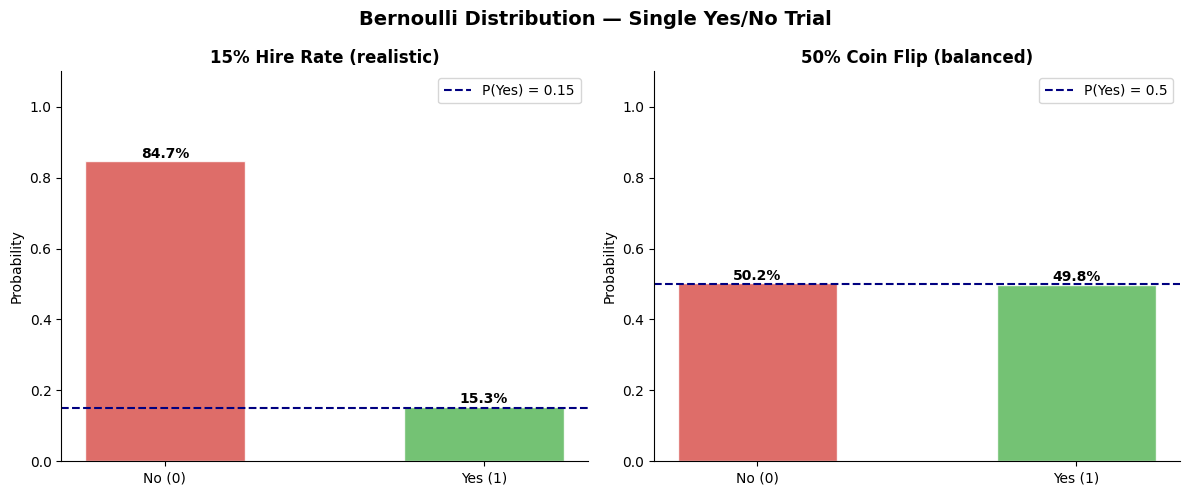


Bernoulli(p=0.15):
  Mean = 0.15  (interpreted as: 15% of outcomes are 1)
  Std Dev = 0.357

Bernoulli(p=0.5):
  Mean = 0.5  (interpreted as: 50% of outcomes are 1)
  Std Dev = 0.500


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Bernoulli Distribution — Single Yes/No Trial", fontsize=14, fontweight='bold')

for ax, p, title in zip(
    axes,
    [0.15, 0.50],
    ['15% Hire Rate (realistic)', '50% Coin Flip (balanced)']
):
    outcomes = np.random.binomial(n=1, p=p, size=2000)
    counts = pd.Series(outcomes).value_counts().sort_index()
    labels = ['No (0)', 'Yes (1)']
    colors = ['#d9534f', '#5cb85c']

    bars = ax.bar(labels, counts.values / len(outcomes),
                  color=colors, alpha=0.85, edgecolor='white', width=0.5)

    # Annotate bars
    for bar, val in zip(bars, counts.values / len(outcomes)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.1%}', ha='center', fontweight='bold')

    ax.axhline(y=p, color='navy', linestyle='--', linewidth=1.5,
               label=f'P(Yes) = {p}')
    ax.set_ylim(0, 1.1)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Probability')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('bernoulli_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
for p in [0.15, 0.50]:
    print(f"\nBernoulli(p={p}):")
    print(f"  Mean = {p}  (interpreted as: {p*100:.0f}% of outcomes are 1)")
    print(f"  Std Dev = {np.sqrt(p*(1-p)):.3f}")




### Distribution 4: The Binomial Distribution

#### The Intuition

The Bernoulli distribution models *one* coin flip. What if you flip the coin *10 times* and ask: "How many times did I get heads?"

That's the **Binomial distribution** — it counts how many successes occur across multiple independent yes/no trials.

Real-world examples:
- Out of 20 customers who saw an ad, how many clicked it?
- Out of 50 packages shipped today, how many arrived on time?
- Out of 100 job applications, how many got interviews?

It's defined by two parameters:
- `n` — number of trials
- `p` — probability of success on each trial

```python
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Binomial Distribution — Counting Successes Across n Trials",
             fontsize=14, fontweight='bold')

scenarios = [
    (10, 0.5, 'Coin Flips\nn=10, p=0.5', 'steelblue'),
    (20, 0.15, 'Ad Click-throughs\nn=20, p=0.15', 'tomato'),
    (50, 0.8, 'On-Time Deliveries\nn=50, p=0.8', 'mediumseagreen'),
]

for ax, (n, p, title, color) in zip(axes, scenarios):
    data = np.random.binomial(n=n, p=p, size=5000)
    x = np.arange(0, n+1)
    theoretical = stats.binom.pmf(x, n, p)

    # Histogram
    unique, counts = np.unique(data, return_counts=True)
    ax.bar(unique, counts/len(data), color=color, alpha=0.6,
           edgecolor='white', label='Simulated')

    # Theoretical line
    ax.plot(x, theoretical, 'ko-', markersize=4, linewidth=1.5,
            label='Theoretical PMF')

    mean_val = n * p
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = n×p = {mean_val:.1f}')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Number of Successes')
    ax.set_ylabel('Probability')
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('binomial_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Show the elegant formula for mean and std
for n, p, label, _ in scenarios:
    mean = n * p
    std = np.sqrt(n * p * (1 - p))
    print(f"{label.split(chr(10))[0]}: Mean = {mean:.1f}, Std Dev = {std:.2f}")
```

**The elegant formulas (intuitive versions):**
- **Mean = n × p** — "If I run 50 trials with 80% success, I expect 50 × 0.8 = 40 successes"
- **Std Dev = √(n × p × (1 - p))** — uncertainty grows with more trials, but shrinks as p approaches 0 or 1

Notice how when p=0.5 (coin flips), the distribution is symmetric and bell-shaped — it's actually approaching a Normal distribution! This is the Central Limit Theorem hinting at itself.

---

### Distribution 5: The Poisson Distribution

#### The Intuition

Imagine you manage a customer support team. You know that, on average, you receive 4 support tickets per hour. But you never receive *exactly* 4 — sometimes it's 1, sometimes it's 7, sometimes it's 10.

The **Poisson distribution** models the **count of random events occurring in a fixed interval of time or space**, when events happen independently at a known average rate.

It answers the question: *"If I expect λ events on average, what's the probability I'll see exactly k events?"*

Real-world examples:
- Emails arriving per hour
- Customers entering a store per minute
- Website errors per day
- Accidents at an intersection per month
- Calls to a call center per shift

```python
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Poisson Distribution — Random Event Counts in Fixed Intervals",
             fontsize=14, fontweight='bold')

lambdas = [
    (1,  'Rare events\nλ=1/hour', 'tomato'),
    (4,  'Moderate rate\nλ=4/hour', 'steelblue'),
    (10, 'Busy period\nλ=10/hour', 'mediumseagreen'),
]

for ax, (lam, title, color) in zip(axes, lambdas):
    data = np.random.poisson(lam=lam, size=5000)
    x = np.arange(0, data.max()+1)
    theoretical = stats.poisson.pmf(x, lam)

    unique, counts = np.unique(data, return_counts=True)
    ax.bar(unique, counts/len(data), color=color, alpha=0.65,
           edgecolor='white', label='Simulated')
    ax.plot(x, theoretical, 'ko-', markersize=4, linewidth=1.5,
            label='Theoretical PMF')
    ax.axvline(lam, color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = λ = {lam}')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Event Count')
    ax.set_ylabel('Probability')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('poisson_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# A beautiful property of Poisson: mean == variance
print("Poisson's unique property: Mean = Variance = λ")
for lam, label, _ in lambdas:
    data = np.random.poisson(lam=lam, size=100000)
    print(f"  λ={lam:2d} | Mean={data.mean():.2f} | Variance={data.var():.2f} | Std Dev={data.std():.2f}")
```

**The Poisson's unique property:** Mean = Variance = λ (lambda)

This means if λ = 4, the average count is 4 *and* the variance is 4. As λ increases, the distribution spreads wider and starts looking more bell-shaped — again, the Normal distribution appears as an approximation of the Poisson for large λ. A beautiful recurring pattern.

> Notice the shape: for small λ, the distribution is right-skewed (zero is common, high counts are rare). As λ grows, it becomes increasingly symmetric.

---

### Distribution 6: The Exponential Distribution

#### The Intuition

If the Poisson distribution asks "how many events occur in an hour?", the Exponential distribution asks the complementary question: **"How long do I wait between events?"**

If buses arrive at a Poisson rate (randomly, averaging every 10 minutes), then the *waiting time* between buses follows an Exponential distribution.

Real-world examples:
- Time between customer service calls
- Time until a machine component fails
- Time between purchases by the same customer
- Delivery times for expedited shipping
- Time between website crashes

The defining property is **memorylessness**: if you've already waited 10 minutes for a bus and it hasn't arrived, your remaining wait time has the *same distribution* as if you'd just arrived at the stop. The bus has no memory of how long you've been waiting.

```python
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Exponential Distribution — Waiting Times Between Events",
             fontsize=14, bbox_inches='tight', fontweight='bold')

# scale = mean wait time (= 1/rate)
scales = [
    (1,   'Very Frequent Events\nMean wait = 1 min', 'tomato'),
    (3.5, 'Moderate Wait\nMean wait = 3.5 days', 'steelblue'),
    (10,  'Infrequent Events\nMean wait = 10 days', 'mediumseagreen'),
]

for ax, (scale, title, color) in zip(axes, scales):
    data = np.random.exponential(scale=scale, size=3000)
    x = np.linspace(0, data.max(), 300)
    theoretical = stats.expon.pdf(x, scale=scale)

    ax.hist(data, bins=50, density=True, color=color, alpha=0.6,
            edgecolor='white', linewidth=0.4, label='Simulated')
    ax.plot(x, theoretical, 'k-', linewidth=2, label='Theoretical')
    ax.axvline(scale, color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {scale}')
    ax.axvline(np.median(data), color='navy', linestyle=':', linewidth=1.5,
               label=f'Median ≈ {np.median(data):.1f}')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Wait Time')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('exponential_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Notice: median < mean for exponential (right skew)
for scale, label, _ in scales:
    data = np.random.exponential(scale=scale, size=100000)
    print(f"Scale={scale:4.1f} | Mean={data.mean():.2f} | Median={np.median(data):.2f} | "
          f"Std Dev={data.std():.2f} | Skewness={pd.Series(data).skew():.2f}")
```

**Key observations from the output:**
- The curve always peaks at 0 — short waits are always the most probable
- Mean > Median — right-skewed (confirmed by positive skewness values)
- Standard deviation equals the mean exactly! (std = scale = mean) — a unique Exponential property

The Exponential is deeply connected to the Poisson: if events arrive at a Poisson rate, the gap between them is Exponential. They're two sides of the same coin.

---

## 6. Building Conceptual Connections

Now that you've seen all six distributions, let's step back and see the architecture of relationships between them.

```python
# Side-by-side: how mean/std behave differently across distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("How Mean and Std Dev Behave Differently Across Distributions",
             fontsize=14, fontweight='bold')

datasets = {
    'Normal\n(symmetric)': (np.random.normal(50, 10, 3000), 'steelblue'),
    'Uniform\n(flat)': (np.random.uniform(30, 70, 3000), 'cornflowerblue'),
    'Exponential\n(right-skewed)': (np.random.exponential(10, 3000), 'tomato'),
    'Lognormal\n(salary-like)': (np.random.lognormal(3.5, 0.7, 3000), 'mediumpurple'),
    'Poisson\n(count data)': (np.random.poisson(8, 3000).astype(float), 'goldenrod'),
    'Binomial\n(n=20, p=0.3)': (np.random.binomial(20, 0.3, 3000).astype(float), 'mediumseagreen'),
}

for ax, (name, (data, color)) in zip(axes.flat, datasets.items()):
    mu, sigma = data.mean(), data.std()
    ax.hist(data, bins=40, density=True, color=color, alpha=0.7,
            edgecolor='white', linewidth=0.3)
    ax.axvline(mu, color='black', linestyle='--', linewidth=2, label=f'μ={mu:.1f}')
    ax.axvspan(mu - sigma, mu + sigma, alpha=0.15, color='black',
               label=f'±1σ ({sigma:.1f})')
    # Check how much data is within 1 std dev
    within_1std = np.mean(np.abs(data - mu) <= sigma) * 100
    ax.set_title(f'{name}\n{within_1std:.0f}% within ±1σ', fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
```

### The Critical Lesson: ±1 Standard Deviation Doesn't Always Mean 68%

The 68-95-99.7 rule is **only for Normal distributions**. Look at what you'll see in the chart:

| Distribution | % within ±1 std dev |
|---|---|
| Normal | ~68% |
| Uniform | ~58% |
| Exponential | ~75–80% |
| Lognormal | ~70–80% |
| Poisson | ~68–75% |

**This is why knowing the shape of your data matters.** If you assume normality and apply the 68% rule to salary data (which is lognormal), your estimates will be wrong. Shape isn't just aesthetic — it changes the math.

### Why Skewed Distributions Affect Averages

```python
# Dramatic demonstration: same std dev, different skewness, different story
np.random.seed(7)

symmetric_salaries = np.random.normal(70000, 20000, 1000)
skewed_salaries = np.random.lognormal(np.log(65000), 0.6, 1000)

# Force same mean approximately
skewed_salaries = skewed_salaries * (symmetric_salaries.mean() / skewed_salaries.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Same Mean, Very Different Stories", fontsize=14, fontweight='bold')

for ax, data, title, color in zip(
    axes,
    [symmetric_salaries, skewed_salaries],
    ['Symmetric Salary Distribution', 'Right-Skewed Salary Distribution (Realistic)'],
    ['steelblue', 'tomato']
):
    ax.hist(data, bins=50, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=2,
               label=f'Mean: ${data.mean():,.0f}')
    ax.axvline(np.median(data), color='red', linestyle=':', linewidth=2,
               label=f'Median: ${np.median(data):,.0f}')
    ax.axvline(pd.Series(data).mode()[0], color='green', linestyle='-.',
               linewidth=2, label=f'Mode: ~${pd.Series(data.round(-3)).mode()[0]:,.0f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Salary ($)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('skewness_effect.png', dpi=150, bbox_inches='tight')
plt.show()
```

**The story this tells:**

In a symmetric distribution, mean, median, and mode are all nearly identical — they all point to the "typical" person's salary. But in the skewed distribution (which is how real salaries actually behave):

- The **mode** (most common salary) is much lower
- The **median** (middle person) is lower than the mean
- The **mean** is pulled up by a small number of very high earners

When politicians debate "average" wages, they're usually using the mean. The typical worker's experience is much better reflected by the median. This is a real-world distribution problem, not just a math problem.

---

## 7. Formulas — With Intuition, Not Memorization

Here's a reference table of the key formulas. Don't memorize these — understand what each part *means*.

```python
# Visual formula reference card
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

table_data = [
    ['Distribution', 'Parameters', 'Mean', 'Std Dev', 'Shape'],
    ['Normal',       'μ, σ',       'μ',    'σ',       'Symmetric bell'],
    ['Uniform',      'a, b',       '(a+b)/2', '(b-a)/√12', 'Flat rectangle'],
    ['Bernoulli',    'p',          'p',    '√(p(1-p))', 'Two bars'],
    ['Binomial',     'n, p',       'n×p',  '√(n×p×(1-p))', 'Bell-like'],
    ['Poisson',      'λ',          'λ',    '√λ',       'Right-skewed → bell'],
    ['Exponential',  'λ (rate)',   '1/λ',  '1/λ',      'Decaying curve'],
]

colors = [['#2c3e50']*5] + [['#f8f9fa', '#eaf4fb', '#fef9e7', '#fdf2f8', '#eafaf1']]*(len(table_data)-1)
header_colors = [['#2c3e50']*5]

table = ax.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(11)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#f5f5f5' if row % 2 == 0 else 'white')
    cell.set_edgecolor('#cccccc')
    cell.set_height(0.13)

ax.set_title('Distribution Formula Reference — Intuitive Summary',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('formula_reference.png', dpi=150, bbox_inches='tight')
plt.show()
```

**What each formula part means intuitively:**

- **Normal μ, σ:** "The bell is centered at μ, and σ controls how wide it is."
- **Binomial n×p:** "Run 100 trials with 30% success rate → expect 30 successes." Simple multiplication.
- **Poisson √λ:** "The more events you expect, the more variable the count — but it grows as the square root, so it grows slower than the mean."
- **Exponential 1/λ:** "If events happen at rate λ per hour, you wait an average of 1/λ hours." Rate and wait time are reciprocals.

---

## 8. The Final Mental Model

Let's assemble everything into one coherent framework you can carry with you.

```python
# Final summary visualization — the mental model map
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#1a1a2e')

ax = fig.add_subplot(111)
ax.set_facecolor('#1a1a2e')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, 'The Probability Distribution Mental Model',
        ha='center', va='center', fontsize=16, fontweight='bold', color='white')

# Core concept boxes
boxes = [
    # (x, y, width, height, text, color)
    (0.3, 7.5, 2.2, 1.2,
     'RAW DATA\nNumbers in columns', '#16213e'),
    (3.8, 7.5, 2.4, 1.2,
     'DESCRIPTIVE STATS\nMean, Median, Std Dev\nQuartiles, Skewness', '#0f3460'),
    (7.3, 7.5, 2.4, 1.2,
     'DISTRIBUTION\nComplete shape picture\nProbabilities for any value', '#533483'),

    # Distribution types
    (0.3, 4.5, 1.5, 1.8,
     'NORMAL\nBell curve\nMany factors adding', '#1a6b3c'),
    (2.0, 4.5, 1.5, 1.8,
     'UNIFORM\nFlat\nEqual chance all values', '#1a4b7c'),
    (3.7, 4.5, 1.5, 1.8,
     'BERNOULLI\n2 outcomes\nYes/No events', '#7c3d1a'),
    (5.4, 4.5, 1.5, 1.8,
     'BINOMIAL\nCount successes\nn trials × p chance', '#6b1a5a'),
    (7.1, 4.5, 1.5, 1.8,
     'POISSON\nCount events\nRandom rate λ', '#1a5e6b'),
    (8.8, 4.5, 1.5, 1.8,
     'EXPONENTIAL\nWaiting times\nBetween events', '#6b5a1a'),

    # Key questions
    (0.3, 1.5, 4.5, 2.2,
     'ASK ABOUT YOUR DATA:\n• Is it counts? → Poisson / Binomial\n'
     '• Is it yes/no? → Bernoulli\n• Is it time between events? → Exponential\n'
     '• Is it symmetric? → Normal\n• Is it truly random? → Uniform', '#16213e'),
    (5.0, 1.5, 4.7, 2.2,
     'SKEWNESS TELLS YOU:\n• Mean > Median → Right skew (salary, delivery)\n'
     '• Mean < Median → Left skew (rare)\n• Mean ≈ Median → Symmetric\n'
     '• High skew → Mean is misleading\n• Use median for skewed data', '#16213e'),
]

for x, y, w, h, text, color in boxes:
    rect = plt.Rectangle((x, y), w, h, facecolor=color,
                          edgecolor='white', linewidth=1, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=7.5, color='white', fontweight='bold',
            multialignment='center')

# Arrows between top row
for x_start, x_end in [(2.5, 3.8), (6.2, 7.3)]:
    ax.annotate('', xy=(x_end, 8.1), xytext=(x_start, 8.1),
                arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

# Row labels
ax.text(0.1, 9.0, 'Step 1', color='#aaaaaa', fontsize=8, style='italic')
ax.text(0.1, 6.8, 'Step 2', color='#aaaaaa', fontsize=8, style='italic')
ax.text(0.1, 4.0, 'Step 3', color='#aaaaaa', fontsize=8, style='italic')

ax.text(5, 0.4,
        '"Every dataset has a shape. Understanding that shape is the foundation of statistical thinking."',
        ha='center', va='center', fontsize=10, color='#dddddd', style='italic')

plt.tight_layout()
plt.savefig('mental_model.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
```

---

## The Final Summary: What You Now Know

Here's the complete mental model you've built:

**1. Data always has a shape.** Numbers aren't just numbers — they have patterns, centers, spreads, and tails. Your first job as a data scientist is always to *look* at the shape.

**2. Descriptive statistics compress the shape.** Mean, median, std deviation — these are useful summaries, but they lose information. Two datasets can have identical statistics and look completely different.

**3. Distributions are named shapes.** When you recognize that your data is "Poisson-like" or "exponentially distributed," you've unlocked a huge toolkit of pre-existing mathematical knowledge about how that data behaves.

**4. Choose your statistic based on the shape.** Skewed data? Use median, not mean. Count data? Think Poisson. Symmetric, continuous? Think Normal.

**5. The distributions are connected.** Bernoulli → Binomial (many trials). Poisson ↔ Exponential (two sides of random events). Binomial → Normal (large n). Poisson → Normal (large λ). These aren't separate tools — they're a family.

**The question to ask every time you see a new dataset:**

> *"What kind of real-world process generated this data — and what shape should I expect that process to produce?"*

Answer that question well, and you've already done half the work of data analysis.

---

*You now have the statistical intuition that most data scientists take months to develop. From here, you're ready to explore hypothesis testing, confidence intervals, and eventually — when the time is right — the statistical foundations of machine learning.*
